# Explore generated samples

C:\Users\truok\AppData\Local\Temp\ipykernel_17800\206974481.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm').copy()


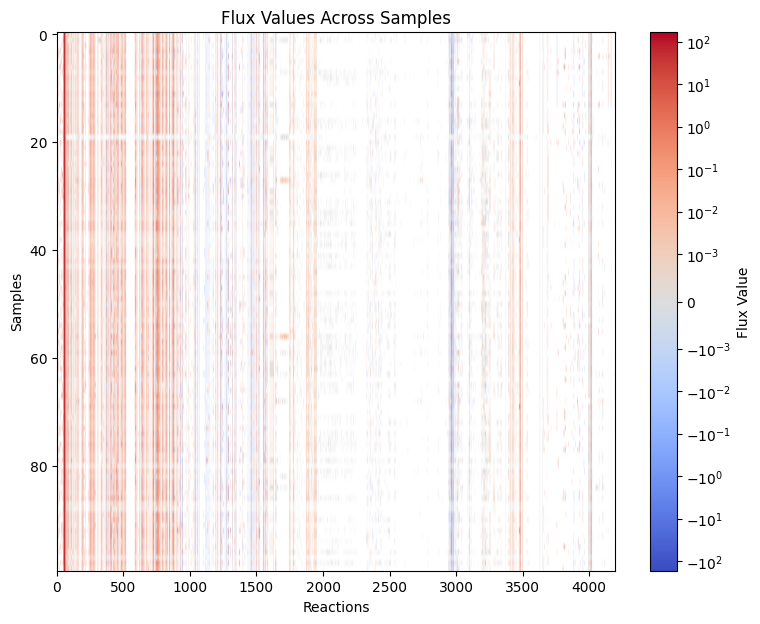

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib import cm
from yeast9_reactions import inputs, outputs

DATA_PATH = './data/2025-11-10_yeast9_data_100_samples.csv'

matrix = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1)

plt.figure(figsize=(9, 7))
plt.title("Flux Values Across Samples")
plt.xlabel("Reactions")
plt.ylabel("Samples")

cmap = cm.get_cmap('coolwarm').copy()
# Set the middle (zero) color to white
cmap.set_bad('white')

# Replace zeros with NaN so they appear as 'bad' in the colormap
matrix_plot = matrix.copy()
matrix_plot[matrix_plot == 0] = np.nan

plt.imshow(matrix_plot, cmap=cmap, aspect='auto', norm=SymLogNorm(linthresh=1e-3))
plt.colorbar(label="Flux Value")
plt.show()

### Display means and variances

In [4]:
df = pd.read_csv(DATA_PATH)
# Drop inputs
df = df.drop(columns=inputs, errors='ignore')

abs_mean = df.abs().mean()
log_abs_mean = np.log1p(abs_mean)
variance = df.var()

stats = pd.DataFrame({
    'abs_mean': abs_mean,
    'log_abs_mean': log_abs_mean,
    'variance': variance
})

TOP = 50
print(f'Top {TOP} fluxes sorted by abs mean')
top_df = stats.sort_values('abs_mean', ascending=False).head(TOP)
top_df.style.format("{:.4f}")

Top 50 fluxes sorted by abs mean


,abs_mean,log_abs_mean,variance
r_0438_flux,70.8260,4.2742,2166.6282
r_2096_flux,65.1379,4.1917,1897.0702
r_1110_flux,51.2014,3.9551,1134.1063
r_0226_flux,47.2434,3.8763,939.6949
r_0439_flux,35.2007,3.5891,540.6617
r_1697_flux,33.9434,3.5537,580.4410
r_1672_flux,33.9434,3.5537,580.4410
r_1245_flux,33.8760,3.5518,808.7745
r_1277_flux,30.9711,3.4648,476.1522
r_2100_flux,29.1284,3.4055,436.0282


In [5]:
# Inspect a specific range of fluxes by rank
start = 500
end   = start + 10

range_df = stats.sort_values('abs_mean', ascending=False).iloc[start:end]
print(f'Fluxes ranked {start}–{end-1} by abs mean')
range_df.style.format("{:.4f}")

Fluxes ranked 500–509 by abs mean


,abs_mean,log_abs_mean,variance
r_0235_flux,0.0325,0.0320,0.0004
r_0234_flux,0.0325,0.0320,0.0004
r_0241_flux,0.0325,0.0320,0.0004
r_0240_flux,0.0325,0.0320,0.0004
r_0231_flux,0.0325,0.0320,0.0004
r_2054_flux,0.0325,0.0320,0.0004
r_2053_flux,0.0325,0.0320,0.0004
r_1977_flux,0.0325,0.0320,0.0004
r_0698_flux,0.0325,0.0320,0.0004
r_0317_flux,0.0325,0.0320,0.0004


In [6]:
BOTTOM = 10
print(f'Bottom {BOTTOM} fluxes sorted by abs mean')
bottom_df = stats.sort_values('abs_mean', ascending=False).tail(BOTTOM)
bottom_df.style.format("{:.4f}")

Bottom 10 fluxes sorted by abs mean


,abs_mean,log_abs_mean,variance
r_4732_flux,0.0000,0.0000,0.0000
r_4727_flux,0.0000,0.0000,0.0000
r_4726_flux,0.0000,0.0000,0.0000
r_4725_flux,0.0000,0.0000,0.0000
r_4723_flux,0.0000,0.0000,0.0000
r_4755_flux,0.0000,0.0000,0.0000
r_4754_flux,0.0000,0.0000,0.0000
r_4753_flux,0.0000,0.0000,0.0000
r_4752_flux,0.0000,0.0000,0.0000
r_0017_flux,0.0000,0.0000,0.0000


### Inspect single reaction by name

In [7]:
reaction = "r_2111_flux"

value_abs_mean = stats.loc[reaction, "abs_mean"]
value_log_abs_mean = stats.loc[reaction, "log_abs_mean"]
value_variance = stats.loc[reaction, "variance"]

print("Reaction:", reaction)
print("Absolute mean:", value_abs_mean)
print("Log absolute mean:", value_log_abs_mean)
print("Variance:", value_variance)

sorted_by_abs_mean = stats.sort_values("abs_mean", ascending=False)
rank = sorted_by_abs_mean.index.get_loc(reaction) + 1   # +1 for 1-based rank

print("Rank by absolute mean:", rank)

Reaction: r_2111_flux
Absolute mean: 0.8811113913476254
Log absolute mean: 0.6318627677827431
Variance: 0.30003077810396067
Rank by absolute mean: 116


### Compute weights

In [8]:
def compute_output_sampling_weights(
    data_path=DATA_PATH,
    inputs_list=inputs,
    outputs_list=outputs,
    boost_dict=None,   # e.g. {"r_2111_flux": 10.0}
    min_weight=1e-8,
    temperature=1.0
):
    """
    Returns:
        weights: numpy array of length len(outputs_list) with normalized probabilities
        stats: DataFrame with abs_mean, variance, log_abs_mean for all flux columns (index includes '_flux')
    """
    df_all = pd.read_csv(data_path)
    df = df_all.drop(columns=inputs_list, errors='ignore')

    # ensure flux columns are present with _flux suffix
    flux_cols = [f"{o}_flux" for o in outputs_list]

    abs_mean = df.abs().mean()
    variance = df.var()
    log_abs_mean = np.log1p(abs_mean)   # log(1 + abs_mean)

    stats = pd.DataFrame({
        "abs_mean": abs_mean,
        "variance": variance,
        "log_abs_mean": log_abs_mean
    })

    # Build weight vector for outputs in the same order as outputs_list
    w_list = []
    for col in flux_cols:
        if col in stats.index:
            w_list.append(stats.loc[col, "log_abs_mean"])
        else:
            w_list.append(min_weight)

    weights = np.array(w_list, dtype=np.float64)

    # boost given reactions
    if boost_dict:
        for rxn_name, factor in boost_dict.items():
            if not rxn_name.endswith("_flux"):
                rxn_key = f"{rxn_name}_flux"
            else:
                rxn_key = rxn_name
            if rxn_key in flux_cols:
                idx = flux_cols.index(rxn_key)
                weights[idx] = weights[idx] * float(factor)

    # replace NaN, non-finite or zero with small weight
    weights = np.nan_to_num(weights, nan=min_weight, posinf=min_weight, neginf=min_weight)
    weights = np.where(weights == 0, min_weight, weights)

    # Softmax with temperature
    exp_weights = np.exp(weights / temperature)
    weights = exp_weights / np.sum(exp_weights)

    return weights, stats

In [12]:

boost_dict = {"r_2111_flux": 6.7}
temperature = 2.0

weights, stats = compute_output_sampling_weights(
    data_path=DATA_PATH,
    inputs_list=inputs,
    outputs_list=outputs,
    boost_dict=boost_dict,
    temperature=temperature
)

print(f"Prepared sampling weights for {len(weights)} outputs. Sum={weights.sum():.6f}")

# Global sorted indices (largest -> smallest)
sorted_global = np.argsort(weights)[::-1]

# TOP RANKS
top_k = 10
print(f"\nTop {top_k} weighted outputs (global ranks 0–{top_k-1}):")
for rank in range(top_k):
    idx = sorted_global[rank]
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")

# MIDDLE RANKS
start = 500
end   = start + 10
rank_slice = sorted_global[start:end]

print(f"\nWeighted outputs at global ranks {start}–{end-1}:")
for rank, idx in enumerate(rank_slice, start=start):
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")

# BOTTOM RANKS
bottom_k = 10
print(f"\nBottom {bottom_k} weighted outputs (lowest ranks):")
for rank in range(len(weights) - bottom_k, len(weights)):
    idx = sorted_global[rank]
    print(f"rank={rank:4d}  idx={idx:4d}  {outputs[idx]:7s}  weight={weights[idx]:.6e}")


Prepared sampling weights for 4131 outputs. Sum=1.000000

Top 10 weighted outputs (global ranks 0–9):
rank=   0  idx= 334  r_0438   weight=1.937136e-03
rank=   1  idx=1499  r_2111   weight=1.898052e-03
rank=   2  idx=1486  r_2096   weight=1.858851e-03
rank=   3  idx= 859  r_1110   weight=1.651431e-03
rank=   4  idx= 202  r_0226   weight=1.587591e-03
rank=   5  idx= 335  r_0439   weight=1.375238e-03
rank=   6  idx=1140  r_1672   weight=1.351145e-03
rank=   7  idx=1163  r_1697   weight=1.351145e-03
rank=   8  idx= 973  r_1245   weight=1.349841e-03
rank=   9  idx=1002  r_1277   weight=1.292404e-03

Weighted outputs at global ranks 500–509:
rank= 500  idx= 211  r_0236   weight=2.322582e-04
rank= 501  idx= 210  r_0235   weight=2.322582e-04
rank= 502  idx= 280  r_0317   weight=2.322582e-04
rank= 503  idx= 219  r_0244   weight=2.322582e-04
rank= 504  idx=1396  r_1977   weight=2.322582e-04
rank= 505  idx=1216  r_1754   weight=2.322582e-04
rank= 506  idx=1451  r_2053   weight=2.322582e-04
rank=